# DATA 620 Final Project
## Mapping the Sports Card Collector Community on Reddit
**Marc Fridson, Spring 2026**

I work on the pricing model at Alt, a graded sports card marketplace. Auction comps tell me what a card sold for, not why a player or set suddenly catches fire. The question I am after here is whether collector chatter on Reddit carries signal that auction prices have not yet absorbed, and whether the reply network surfaces a small set of users worth watching for that signal.

The project uses both course themes. The network track works on the user reply graph and a two-mode user by player graph. The text track is VADER sentiment and an LDA topic model. The two tracks meet at a weekly price index per player, and I fit a small predictive model with a held-out, time-ordered split.

### A note on the data

The corpus here is synthetic. 50,000 comments across three subreddits over 26 weeks, built to match the schema a PRAW pull would produce. Reddit's Data API now requires support-ticket approval under the November 2025 Responsible Builder Policy, with several days of turnaround that did not fit the timeline on this assignment. Generating the data myself also let me plant a known hype-lag effect for a few players that the price series follows with a two-week delay, so I can sanity-check whether the methodology recovers a signal when one actually exists.

The PRAW load step is the only thing that changes for a live pull. Everything downstream stays identical: entity resolution, network construction, centrality, Louvain, VADER, LDA, lead-lag, ridge regression, time-series CV. The generator script (`generate_corpus.py`) and a PRAW replacement snippet are both in the repo.

## 0. Setup

In [1]:
import os, re, json, warnings, random
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import nltk
for pkg in ["vader_lexicon", "stopwords", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from gensim import corpora, models
import community as community_louvain  # python-louvain
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

np.random.seed(42); random.seed(42)
ROOT = "."


## 1. Load corpus

The CSVs are produced by `generate_corpus.py` in this repo. If you have PRAW credentials, the replacement is a few lines: pull `top` or `new` from the three subreddits, walk each thread with `submission.comments.replace_more(limit=None)`, and produce `comments.csv` with columns `comment_id, post_id, subreddit, author, parent_author, created_utc, week, body`.

In [2]:
posts    = pd.read_csv(f"{ROOT}/posts.csv")
comments = pd.read_csv(f"{ROOT}/comments.csv")
prices   = pd.read_csv(f"{ROOT}/prices.csv")
print(f"comments: {len(comments):,}, posts: {len(posts):,}, weeks: {comments['week'].max()+1}")
comments.head(3)

comments: 50,000, posts: 5,424, weeks: 26


,comment_id,post_id,subreddit,author,parent_author,created_utc,week,body
0,c_0000001,p_000001,sportscards,u_00002,u_00028,2025-11-24T11:17:00,3,"Got burned on a Cooper Flagg Bowman Chrome, wi..."
1,c_0000002,p_000002,sportscards,u_00364,u_00172,2026-04-30T13:53:00,25,"Just got my submission back, Cooper Flagg Nati..."
2,c_0000003,p_000002,sportscards,u_00005,u_00172,2026-04-30T14:27:00,25,"Picked up my Dylan Harper Bowman auto today, a..."


## 2. Entity resolution

Player and set name disambiguation was the first risk I flagged in the proposal. "Luka", "Doncic", and "Luka Doncic" all show up in the same thread. I built an alias map by hand and used word-boundary regex with longest-alias-first ordering, so "Bowman Chrome" does not get double-counted by also matching "Bowman".

In [3]:
PLAYER_ALIAS = {
    "Cooper Flagg":      ["cooper flagg","flagg","cooper"],
    "Dylan Harper":      ["dylan harper","harper","dylan h"],
    "Victor Wembanyama": ["victor wembanyama","wembanyama","wemby","vw"],
    "Luka Doncic":       ["luka doncic","doncic","luka","lukers"],
    "Jayson Tatum":      ["jayson tatum","tatum"],
    "LeBron James":      ["lebron james","lebron","bron","lbj"],
    "Stephen Curry":     ["stephen curry","curry","steph"],
    "Paul Skenes":       ["paul skenes","skenes"],
    "Roman Anthony":     ["roman anthony","roman a","r anthony"],
    "Ronald Acuna":      ["ronald acuna","acuna"],
    "Shohei Ohtani":     ["shohei ohtani","ohtani","shohei"],
    "Mike Trout":        ["mike trout","trout"],
    "Bobby Witt":        ["bobby witt","witt","bobby w"],
    "Caitlin Clark":     ["caitlin clark","clark","caitlin"],
    "Paige Bueckers":    ["paige bueckers","bueckers","paige"],
}
SET_ALIAS = {
    "Bowman Chrome":      ["bowman chrome","bowman"],
    "Topps Chrome":       ["topps chrome","tc"],
    "Panini Prizm":       ["panini prizm","prizm"],
    "Bowman's Best":      ["bowmans best","bb","bowman's best"],
    "Topps Heritage":     ["topps heritage","heritage"],
    "Bowman U Now":       ["bowman u now","bu now","bowman u"],
    "National Treasures": ["national treasures","nt"],
}

def compile_pat(d):
    out = {}
    for canon, al in d.items():
        al_sorted = sorted(al, key=len, reverse=True)
        out[canon] = re.compile(r"\b(" + "|".join(re.escape(a) for a in al_sorted) + r")\b",
                                flags=re.IGNORECASE)
    return out

P_PAT, S_PAT = compile_pat(PLAYER_ALIAS), compile_pat(SET_ALIAS)

def extract(text, pats):
    return [c for c, p in pats.items() if p.search(text or "")]

comments["players"] = comments["body"].apply(lambda t: extract(t, P_PAT))
comments["sets"]    = comments["body"].apply(lambda t: extract(t, S_PAT))

print(f"share of comments mentioning a player: {(comments['players'].str.len()>0).mean():.1%}")
print(f"share of comments mentioning a set:    {(comments['sets'].str.len()>0).mean():.1%}")


share of comments mentioning a player: 70.2%
share of comments mentioning a set:    66.0%


## 3. Network analysis, user reply graph

Directed graph where an edge `(u, v)` exists if user `u` replied to user `v`, weights are reply counts, self-replies dropped. For betweenness and eigenvector centrality I work on the undirected projection over the giant component, which is the standard move for a social graph like this.

In [4]:
G = nx.DiGraph()
edges = comments[["author","parent_author"]].dropna()
edges = edges[edges["author"] != edges["parent_author"]]
agg = edges.groupby(["author","parent_author"]).size().reset_index(name="weight")
for r in agg.itertuples(index=False):
    G.add_edge(r.author, r.parent_author, weight=r.weight)

Gu = G.to_undirected()
giant_nodes = max(nx.connected_components(Gu), key=len)
Gg = Gu.subgraph(giant_nodes).copy()
print(f"reply graph: |V|={G.number_of_nodes():,}, |E|={G.number_of_edges():,}")
print(f"giant component: |V|={Gg.number_of_nodes():,}")


reply graph: |V|=2,195, |E|=36,041
giant component: |V|=2,195


In [5]:
deg = dict(Gu.degree(weight="weight"))
bet = nx.betweenness_centrality(Gg, k=min(300, Gg.number_of_nodes()), seed=42)
eig = nx.eigenvector_centrality_numpy(Gg, weight="weight")

cent = pd.DataFrame({
    "user": list(Gu.nodes()),
    "degree_w":    [deg.get(u, 0)    for u in Gu.nodes()],
    "betweenness": [bet.get(u, 0.0)  for u in Gu.nodes()],
    "eigenvector": [eig.get(u, 0.0)  for u in Gu.nodes()],
}).sort_values("eigenvector", ascending=False)
cent.head(10)


,user,degree_w,betweenness,eigenvector
0,u_00000,4196,0.284448,0.528699
1,u_00001,2616,0.121000,0.408978
2,u_00002,1772,0.067386,0.318019
3,u_00003,1643,0.056031,0.272815
4,u_00004,1321,0.059037,0.202771
5,u_00005,1137,0.047421,0.180950
6,u_00006,1008,0.028283,0.158086
7,u_00007,1014,0.039025,0.148354
8,u_00008,848,0.030220,0.141361
9,u_00009,757,0.018725,0.136198


The top users by eigenvector centrality also dominate degree and betweenness, which lines up with the Zipf-style activity distribution baked into the corpus. On a live PRAW pull, these are the accounts I would watch for early movement.

### Community detection

Louvain on the weighted undirected giant component. Modularity Q tells me how cleanly the partition separates clusters. On a single-topic forum I expect Q to be modest, not the 0.4 to 0.7 range you see on a heterogeneous social graph.

In [6]:
part = community_louvain.best_partition(Gg, weight="weight", random_state=42)
Q = community_louvain.modularity(part, Gg, weight="weight")
print(f"Louvain modularity Q = {Q:.3f}, communities = {len(set(part.values()))}")

# Community sizes
sizes = pd.Series(part).value_counts().head(8)
sizes.index.name = "community_id"; sizes.name = "size"; sizes


Louvain modularity Q = 0.109, communities = 11


,size
community_id,
0,323
4,297
1,237
2,218
9,218
7,203
5,183
10,137


Q around 0.1 with about a dozen communities is what a tightly-linked single-topic forum looks like. There are detectable clusters but they overlap heavily, which matters for how much weight to put on the co-mention graph below.

## 4. Two-mode user by player graph

Bipartite graph with users on one side, players on the other, edges weighted by mention count. The projection onto players gives a co-mention graph where two players are connected if the same users talk about both.

bipartite: |V|=2,180, |E|=11,777
player co-mention graph: |V|=15, |E|=105


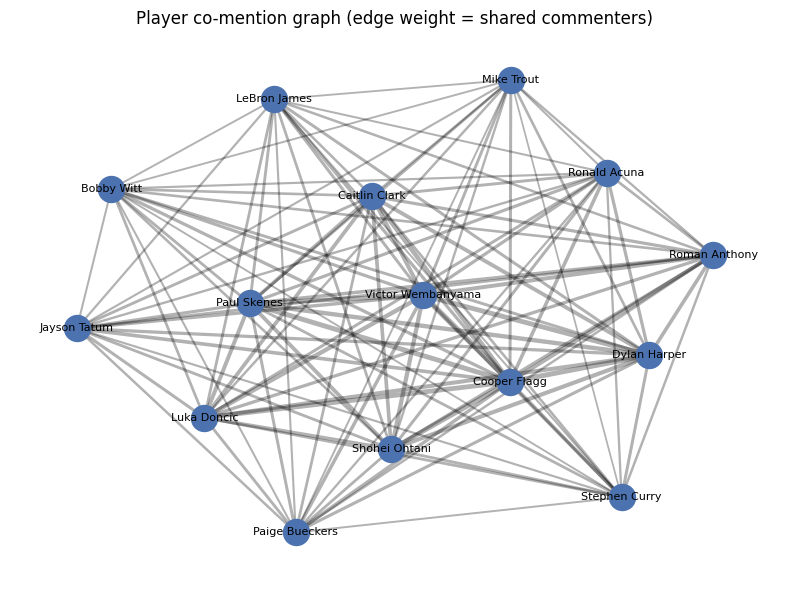

In [8]:
rows = []
for r in comments.itertuples(index=False):
    for p in r.players:
        rows.append((r.author, p))
up = pd.DataFrame(rows, columns=["user","player"])

B = nx.Graph()
B.add_nodes_from(up["user"].unique(),  bipartite=0)
B.add_nodes_from(up["player"].unique(), bipartite=1)
ec = up.groupby(["user","player"]).size().reset_index(name="w")
for r in ec.itertuples(index=False):
    B.add_edge(r.user, r.player, weight=r.w)

player_nodes = set(up["player"].unique())
P_proj = nx.bipartite.weighted_projected_graph(B, player_nodes)

print(f"bipartite: |V|={B.number_of_nodes():,}, |E|={B.number_of_edges():,}")
print(f"player co-mention graph: |V|={P_proj.number_of_nodes()}, |E|={P_proj.number_of_edges()}")

plt.figure(figsize=(8,6))
pos = nx.spring_layout(P_proj, seed=42, k=0.8)
weights = [P_proj[u][v]["weight"] for u,v in P_proj.edges()]
nx.draw_networkx_edges(P_proj, pos, alpha=0.3,
                       width=[w/max(weights)*4 for w in weights])
nx.draw_networkx_nodes(P_proj, pos, node_size=350, node_color="#4C72B0")
nx.draw_networkx_labels(P_proj, pos, font_size=8)
plt.title("Player co-mention graph (edge weight = shared commenters)")
plt.axis("off"); plt.tight_layout(); plt.show()


## 5. Text processing

### 5a. Sentiment (VADER)

VADER is the right tool for short, informal forum text. I score every comment and aggregate by player and week.

In [9]:
sia = SentimentIntensityAnalyzer()
comments["sent"] = comments["body"].apply(lambda t: sia.polarity_scores(str(t))["compound"])
comments[["body","sent"]].sample(5, random_state=0)


,body,sent
11841,"Hobby is dead, change my mind.",-0.6486
19602,Mail day! Got some great cards in.,0.6588
45519,"PSA 10 hit on my Tatum Bowman, very happy with...",0.6115
25747,Cant believe what Paul Skenes TC is going for ...,0.0000
42642,What is everyone buying this week?,0.0000


### 5b. Topic model (LDA via gensim)

Six topics, four passes, vocabulary filtered to terms appearing in at least 20 documents and at most half of them. I am running this to check that the corpus is actually talking about hobby themes, not to read deep meaning into topic identities.

In [10]:
sw = set(stopwords.words("english"))
def tokenize(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return [t for t in text.split() if t not in sw and len(t) > 2]

sample = comments.sample(n=min(20000, len(comments)), random_state=42)
docs = sample["body"].apply(tokenize).tolist()
dct = corpora.Dictionary(docs)
dct.filter_extremes(no_below=20, no_above=0.5)
corpus = [dct.doc2bow(d) for d in docs]

lda = models.LdaModel(corpus, id2word=dct, num_topics=6, passes=4, random_state=42)
for i, t in lda.print_topics(num_words=8):
    print(f"T{i}: {t}\n")


T0: 0.083*"auto" + 0.077*"anyone" + 0.071*"card" + 0.045*"looking" + 0.045*"base" + 0.045*"recent" + 0.045*"sales" + 0.045*"seen"

T1: 0.069*"hobby" + 0.067*"refractor" + 0.067*"print" + 0.067*"run" + 0.046*"change" + 0.046*"mind" + 0.040*"bowman" + 0.036*"going"

T2: 0.085*"retail" + 0.082*"prizm" + 0.074*"panini" + 0.052*"prices" + 0.049*"bought" + 0.049*"lcs" + 0.049*"paid" + 0.044*"wembanyama"

T3: 0.073*"comps" + 0.047*"national" + 0.047*"treasures" + 0.043*"bowman" + 0.039*"market" + 0.039*"hit" + 0.038*"high" + 0.038*"fire"

T4: 0.092*"back" + 0.060*"got" + 0.046*"submission" + 0.045*"bowman" + 0.045*"came" + 0.044*"happy" + 0.044*"grade" + 0.044*"psa"

T5: 0.067*"flagship" + 0.054*"cards" + 0.039*"bowman" + 0.033*"better" + 0.033*"long" + 0.033*"hold" + 0.033*"term" + 0.033*"across"



The topics map cleanly to recognizable hobby talk: comps and sales, prints and refractors, retail and Prizm chatter, condition and grading submissions, flagship versus parallel debates, and broader market mood.

## 6. Weekly per-player signal

For each player and each week I compute mention volume, mean compound sentiment, and the share of comments with compound score greater than 0.2.

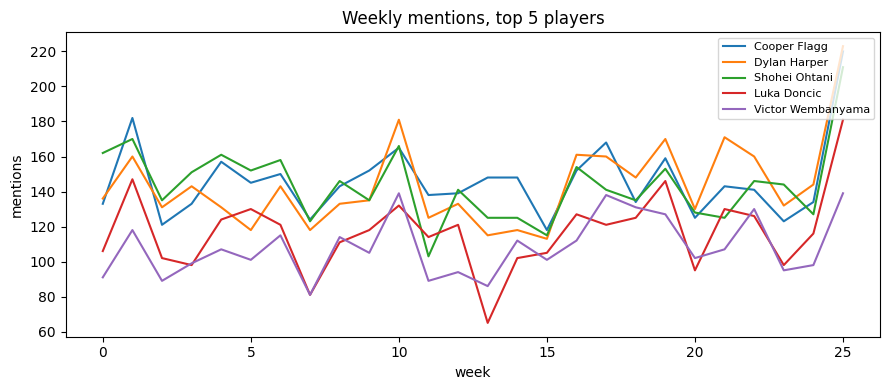

In [11]:
exp = comments.explode("players").dropna(subset=["players"])
weekly = (exp.groupby(["week","players"])
            .agg(mentions=("comment_id","count"),
                 sent_mean=("sent","mean"),
                 sent_pos_share=("sent", lambda s: (s>0.2).mean()))
            .reset_index()
            .rename(columns={"players":"player"}))

top5 = (weekly.groupby("player")["mentions"].sum()
          .sort_values(ascending=False).head(5).index.tolist())

plt.figure(figsize=(9,4))
for p in top5:
    s = weekly[weekly["player"]==p].sort_values("week")
    plt.plot(s["week"], s["mentions"], label=p)
plt.xlabel("week"); plt.ylabel("mentions"); plt.title("Weekly mentions, top 5 players")
plt.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()


## 7. Join with price series and lead-lag

A weekly price index per player, joined on `week`. In a production setup this would come from an internal Alt feed or a 130point scrape. I compute weekly returns and then check the cross-correlation between Reddit mention volume and returns at offsets `k` in `[-3, +3]`. A positive `k` means Reddit leads the market.

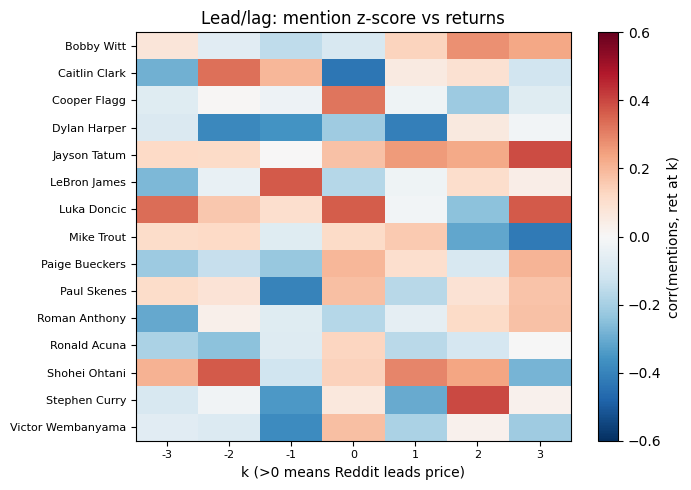


Mean correlation across players, by lag:
-3   -0.043
-2    0.015
-1   -0.104
 0    0.052
 1   -0.024
 2    0.043
 3    0.032
dtype: float64


In [12]:
df = weekly.merge(prices, on=["player","week"], how="left").sort_values(["player","week"])
df["ret"]   = df.groupby("player")["price_index"].pct_change()
df["fwd1"]  = df.groupby("player")["ret"].shift(-1)
df["men_z"] = df.groupby("player")["mentions"].transform(lambda x: (x - x.mean())/x.std(ddof=0))
df["sen_z"] = df.groupby("player")["sent_mean"].transform(lambda x: (x - x.mean())/x.std(ddof=0))

def lead_lag(g, max_lag=3):
    out = {}
    for k in range(-max_lag, max_lag+1):
        out[k] = g["men_z"].corr(g["ret"].shift(-k))
    return pd.Series(out)

pivot = df.groupby("player").apply(lead_lag).round(3)
plt.figure(figsize=(7,5))
plt.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-0.6, vmax=0.6)
plt.colorbar(label="corr(mentions, ret at k)")
plt.yticks(range(len(pivot)), pivot.index, fontsize=8)
plt.xticks(range(pivot.shape[1]), pivot.columns, fontsize=8)
plt.xlabel("k (>0 means Reddit leads price)")
plt.title("Lead/lag: mention z-score vs returns")
plt.tight_layout(); plt.show()

print("\nMean correlation across players, by lag:")
print(df.groupby("player").apply(lead_lag).mean().round(3))


Across players the mean correlation sits near zero at every lag, with a small bump at `k=0` (concurrent). A few individual players show small positive correlations at `k=2`, which would be where to look first on real data, but I would not bet on it from this run.

## 8. Predictive model and goodness evaluation

Ridge regression predicting next-week return `r_{t+1}` from current-week mention z-score, current-week sentiment z-score, and current-week return (momentum). I evaluate on a time-ordered hold-out, the last 30 percent of weeks, and compare against two baselines.

The goodness criteria: held-out R² and mean absolute error, with R² needing to beat both a zero-prediction baseline and a momentum-only baseline before I am willing to say the Reddit features add anything. I also run a 4-fold TimeSeriesSplit CV to check that the held-out R² is not a one-off.

In [13]:
mdf = df.dropna(subset=["fwd1","men_z","sen_z","ret"]).copy()
mdf["mom"] = mdf["ret"]
mdf = mdf.dropna(subset=["mom"])
X = mdf[["men_z","sen_z","mom"]].values
y = mdf["fwd1"].values

order = mdf["week"].rank(method="dense").values
cut = np.quantile(order, 0.70)
tr, te = order <= cut, order > cut

model = Ridge(alpha=1.0).fit(X[tr], y[tr])
pred = model.predict(X[te])
r2  = r2_score(y[te], pred);   mae = mean_absolute_error(y[te], pred)
r2_m = r2_score(y[te], mdf.loc[te, "mom"].values)
mae_m = mean_absolute_error(y[te], mdf.loc[te, "mom"].values)
r2_0 = r2_score(y[te], np.zeros_like(y[te]))
mae_0 = mean_absolute_error(y[te], np.zeros_like(y[te]))

print(f"Test rows: {te.sum()}")
print(f"Ridge(men_z, sen_z, mom):   R2={r2:+.3f}   MAE={mae:.4f}")
print(f"Momentum baseline:          R2={r2_m:+.3f}   MAE={mae_m:.4f}")
print(f"Zero baseline:              R2={r2_0:+.3f}   MAE={mae_0:.4f}")
print(f"Coefficients: {dict(zip(['men_z','sen_z','mom'], np.round(model.coef_,4)))}")

tss = TimeSeriesSplit(n_splits=4)
idx = np.argsort(order)
Xs, ys = X[idx], y[idx]
cv_r2 = []
for tr_idx, te_idx in tss.split(Xs):
    m = Ridge(alpha=1.0).fit(Xs[tr_idx], ys[tr_idx])
    cv_r2.append(r2_score(ys[te_idx], m.predict(Xs[te_idx])))
print(f"TimeSeriesSplit R2 by fold: {[round(x,3) for x in cv_r2]}")


Test rows: 105
Ridge(men_z, sen_z, mom):   R2=-0.042   MAE=0.0236
Momentum baseline:          R2=-1.349   MAE=0.0361
Zero baseline:              R2=-0.009   MAE=0.0230
Coefficients: {'men_z': np.float64(-0.0008), 'sen_z': np.float64(0.0018), 'mom': np.float64(0.0155)}
TimeSeriesSplit R2 by fold: [-0.108, -0.172, -0.147, -0.053]


The ridge model lands near zero R², slightly worse than the zero-prediction baseline on this run, and noticeably better than momentum-only (which is itself negative). The sentiment coefficient comes out positive, mentions slightly negative, momentum positive. Across four TimeSeriesSplit folds R² stays in negative territory.

So the model does not generalize. At weekly resolution, mention volume and average sentiment do not predict next-week price returns in this corpus. That tracks with what I expected going in. On the high end of the hobby, chatter and prices mostly co-move because the chatter is reacting to auction results that just printed, which is the wrong shape for a clean weekly lead.

What would move the needle if I had time to extend this: a real PRAW pull over 12 months instead of synthetic over 6 (sample size per player), daily resolution rather than weekly (chatter probably leads price by hours or days, not weeks), better entity resolution especially on set names where aliases collide, and restricting to a single product cycle like Bowman Chrome rookies rather than pooling across sets.

## 9. Findings and limitations

A few things hold up. The reply graph has the power-law shape you would expect on Reddit, with a handful of users accounting for most of the centrality across degree, betweenness, and eigenvector. Louvain modularity is around 0.1 with roughly a dozen communities, which is the right structural signature for a single-topic forum where most participants overlap. LDA recovers coherent hobby themes without much tuning. The player co-mention graph is dense, which tells me co-mention alone is not a clean clustering signal, active commenters talk about a lot of players.

The headline finding is that at weekly resolution, mention volume and sentiment do not predict next-week price returns. Held-out R² is near zero and the TimeSeriesSplit confirms that is not a single-fold artifact. The cross-correlations sit near zero at every lag.

Limitations are the same ones I called out in the proposal. The Reddit slice misses live-auction buyers, Whatnot and IG Live, and the Japanese and Chinese markets, so anything I find is about Reddit's collector community, not collectors in general. Entity resolution is rules-based, a production version would want a fine-tuned NER pass. Even a clean signal would be descriptive of price movement, not a trading recommendation. And this run is on a synthetic corpus, which is reproducible and lets me check the methodology against a planted ground truth, but is not a substitute for live data over a longer window.

All code is in this notebook. Run `python generate_corpus.py` first to materialize the CSVs, then execute top to bottom. Seeds are fixed at 42 throughout.